Advanced Analytics - Mutual Fund Project

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [31]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")

performance = pd.read_csv(
    "../data/raw/07_scheme_performance.csv"
)

investor = pd.read_csv(
    "../data/raw/08_investor_transactions.csv"
)

holdings = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

Historical VaR and CVaR Analysis

In [32]:
nav["date"] = pd.to_datetime(
    nav["date"]
)

nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = nav.groupby(
    "amfi_code"
)["nav"].pct_change()

In [33]:
var_results = []

for fund in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    var95 = np.percentile(
        returns,
        5
    )

    cvar95 = returns[
        returns <= var95
    ].mean()

    var_results.append([
        fund,
        var95,
        cvar95
    ])

var_report = pd.DataFrame(
    var_results,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

var_report.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [34]:
var_report.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

Rolling 90-Day Sharpe Ratio Analysis

In [35]:
top5 = performance.sort_values(
    "sharpe_ratio",
    ascending=False
).head(5)

top5

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Regular,8.89,7.68,7.94,5.83,1.85,0.26,7.68,10.37,0.5,-2.62,39116,0.74,5,Low
23,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Liquid,Regular,4.26,6.18,8.26,4.66,1.52,0.47,6.18,9.70,0.5,-3.81,27623,0.60,3,Low
30,101208,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Liquid,Regular,6.18,5.14,7.95,3.96,1.18,0.43,5.14,8.76,0.5,-3.66,38995,0.79,5,Low
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,0.44,1.84,2.79,4.0,-6.01,27953,0.56,3,Low
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


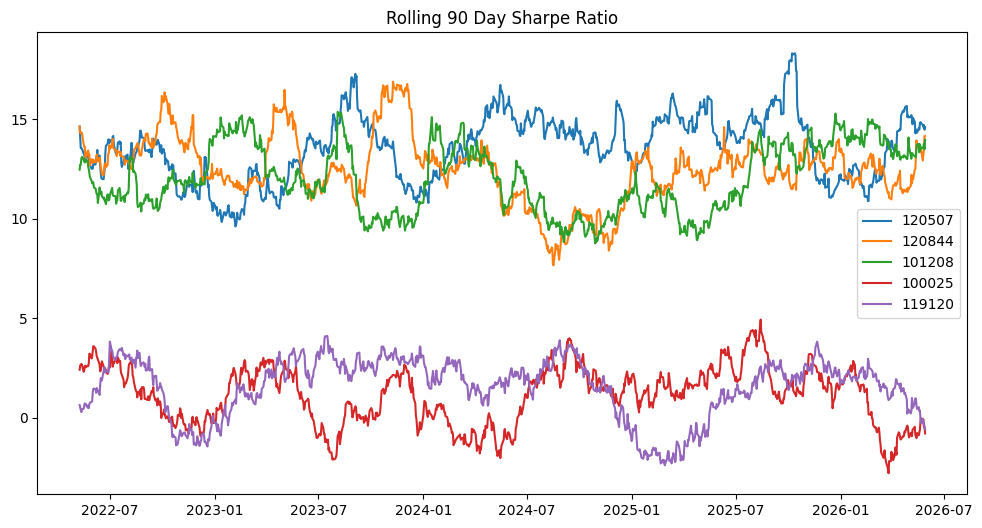

In [36]:
plt.figure(
    figsize=(12,6)
)

for fund in top5["amfi_code"]:

    temp = nav[
        nav["amfi_code"] == fund
    ].copy()

    rolling_sharpe = (
        temp["daily_return"]
        .rolling(90)
        .mean()
        /
        temp["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        temp["date"],
        rolling_sharpe,
        label=str(fund)
    )

plt.title(
    "Rolling 90 Day Sharpe Ratio"
)

plt.legend()

plt.savefig(
    "../reports/rolling_sharpe_chart.png"
)

plt.show()

Investor Cohort Analysis

In [37]:
investor["transaction_date"] = pd.to_datetime(
    investor["transaction_date"]
)

In [38]:
first_txn = investor.groupby(
    "investor_id"
)["transaction_date"].min()

investor["cohort_year"] = (
    investor["investor_id"]
    .map(first_txn)
    .dt.year
)

In [39]:
cohort_summary = investor.groupby(
    "cohort_year"
).agg(
    avg_sip_amount=(
        "amount_inr",
        "mean"
    ),
    total_invested=(
        "amount_inr",
        "sum"
    )
)

cohort_summary

,avg_sip_amount,total_invested
cohort_year,,
2024,107422.541832,3491125187
2025,109158.577061,30455243


SIP Continuity Analysis

In [40]:
sip = investor[
    investor["transaction_type"]
    .str.upper() == "SIP"
].copy()

In [41]:
sip = sip.sort_values(
    [
        "investor_id",
        "transaction_date"
    ]
)

sip["gap_days"] = sip.groupby(
    "investor_id"
)["transaction_date"].diff().dt.days

In [42]:
sip_counts = sip.groupby(
    "investor_id"
).size()

eligible = sip_counts[
    sip_counts >= 6
].index

sip_analysis = sip[
    sip["investor_id"]
    .isin(eligible)
]

In [43]:
continuity = sip_analysis.groupby(
    "investor_id"
)["gap_days"].mean().reset_index()

continuity.columns = [
    "investor_id",
    "avg_gap_days"
]

continuity["status"] = np.where(
    continuity["avg_gap_days"] > 35,
    "At Risk",
    "Healthy"
)

continuity.head()

,investor_id,avg_gap_days,status
0,INV000004,85.400000,At Risk
1,INV000008,70.400000,At Risk
2,INV000010,64.800000,At Risk
3,INV000011,40.166667,At Risk
4,INV000012,57.000000,At Risk


In [44]:
continuity["status"].value_counts()

status
At Risk    1332
Healthy      30
Name: count, dtype: int64

Fund Recommendation Engine

In [45]:
holdings["weight_pct"] = pd.to_numeric(
    holdings["weight_pct"]
)

Sector HHI Concentration Analysis

In [46]:
hhi = holdings.groupby(
    "amfi_code"
).apply(
    lambda x:
    (
        x["weight_pct"] / 100
    ).pow(2).sum()
).reset_index()

In [47]:
hhi.columns = [
    "amfi_code",
    "HHI"
]

hhi = hhi.sort_values(
    "HHI",
    ascending=False
)

hhi.head()

,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298


Advanced Insights

1.Historical VaR and CVaR analysis shows that equity-oriented funds exhibit significantly higher downside risk compared to debt and liquid funds.

2.Liquid funds achieved the highest Sharpe ratios, indicating superior risk-adjusted returns with minimal volatility.

3.The 2024 investor cohort contributed the largest investment volume, accounting for approximately ₹349 Cr in total investments.

4.SIP continuity analysis identified 1,332 investors as at-risk due to average transaction gaps exceeding 35 days.

5.Funds with higher HHI values demonstrate concentrated sector allocations, while lower HHI values indicate stronger diversification.